# **Лабораторная работа 3**
## **Анимация движения секущей прямой к заданной линии на плоскости**

*Коровацкий Александр Сергеевич, 25.03.2025*

### Используем модуль ipyml и функцию FuncAnimation

In [4]:
%matplotlib widget

In [5]:
from matplotlib.animation import FuncAnimation

In [6]:
# ?FuncAnimation

- обязательный аргумент <span style="background-color: lightgray;">fig</span> : графическое окно, в котором будет отображаться
анимация;
- обязательный аргумент <span style="background-color: lightgray;">func</span> : функция одного обязательного аргумента,
которая будет вызываться в каждом кадре;
- НЕобязательный аргумент <span style="background-color: lightgray;">frames</span> со стандартным значением <span style="background-color: lightgray;">None</span> :
последовательность, элементы которой будут определять значение аргумента
функции <span style="background-color: lightgray;">func</span> при последовательной индексации последовательности от
начала до конца;
- НЕобязательный аргумент <span style="background-color: lightgray;">unit_func</span> со стандартным значением <span style="background-color: lightgray;">None</span> :
функция, которая вызывается перед началом анимации;
- НЕобязательный аргумент <span style="background-color: lightgray;">repeat</span> со стандартным значением <span style="background-color: lightgray;">True</span> : нужно ли
повторять анимацию снова после отрисовки всех кадров;
- НЕобязательный аргумент <span style="background-color: lightgray;">interval</span> со стандартным значением <span style="background-color: lightgray;">200</span> :
длительность задержки в миллисекундах между кадрами анимации.


## Задание 3.1. Анимированное построение линии на плоскости

a) $\color{red}{Создайте}$ $\color{red}{анимацию}$ построения графика некоторой явно заданной аналитической функции $y=y(x)$ по значениям $x$, последовательно изменяющимся от $x_{min}$ до $x_{max}$ с
шагом $step$. Выполните задание для $y(x)=(x-5)^3$, $x_{min}=0$, $x_{max}=10$, $step=0.1$.

б)$\color{red}{Создайте}$ $\color{red}{анимацию}$ построения графика параметрически заданной функции $y=y(t)$, $x=x(t)$
по значениям $t$, последовательно изменяющимся от $t_{min}$ до $t_{max}$ с
шагом $step$. Выполните задание для функции из Задания 1.3 в Лб1, согласно Вашему
варианту, для $t_{min}=0$, $t_{max}=10$, $step=0.1$.

##  Реализация Задания 3.1a

In [14]:
import numpy as np

In [16]:
 import matplotlib.pyplot as plt

Импортируем функцию FuncAnimation из модуля animation пакета matplotlib:

In [18]:
from matplotlib.animation import FuncAnimation

Будем строить анимацию для функции вида $y(x) = sin(x)^4$ по значениям $x$, изменяющимся от $x_{min} = 1$ до $x_{max} = 5$ с шагом $step = 0.05$. Определим функцию $y(x)$ с применением оператора def

In [20]:
def y(x):
    return np.sin(x)**4

 Создадим переменные

In [22]:
x_min = 1.; x_max = 5.; step = 0.05

Cоздадим массив x_array равномерно распределенных чисел на отрезке $|x_{min}, x_{max}|$с шагом **$step$** с помощью функции arange. Создадим массив y_array соответствующих значений $y$ с помощью пользовательской функции y

In [24]:
x_array = np.arange(x_min, x_max, step)
y_array = y(x_array)

Из двух массивов x_array и y_array создадим матрицу matrix координат точек графика функции $y(x)$ . Матрица состоит из двух столбцов. Первый столбец матрицы содержит x-координаты точек, второй столбец -- y-координаты точек:

In [26]:
matrix = np.transpose([x_array, y_array])

С помощью функции figure из модуля pyplot создадим графическое окно fig1, в котором в дальнейшем будет отображаться анимация

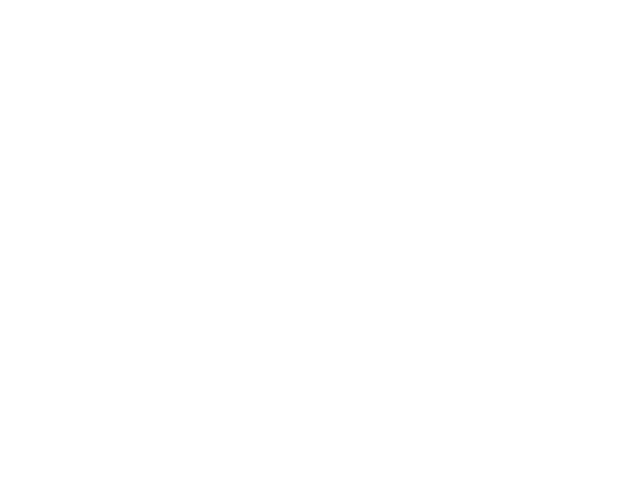

In [28]:
fig1 = plt.figure()

C помощью функции axes из модуля pyplot cоздадим графическую область ax1 и зададим для нее пределы по осям

In [64]:
y_min, y_max = np.min(y_array), np.max(y_array)
ax1 = plt.axes()
plt.axis([x_min-0.5, x_max+0.5, y_min-0.5, y_max+0.5])

(0.5, 5.5, -0.499999995004082, 1.4996930655910048)

С помощью функции plot из пакета pyplot создадим в графической области ax1 графический объект типа Line2D синего цвета, координаты которого пока не определены

In [32]:
line1, = ax1.plot([],[],'b') 
print(type(line1))
line1.get_xdata(), line1.get_ydata()

<class 'matplotlib.lines.Line2D'>


(array([], dtype=float64), array([], dtype=float64))

In [34]:
?line1.get_xdata

Signature: line1.get_xdata(orig=True)
Docstring:
Return the xdata.

If *orig* is *True*, return the original data, else the
processed data.
File:      g:\anaconda\lib\site-packages\matplotlib\lines.py
Type:      method

Определим пользовательскую функцию одного аргумента at_frame1 будет вызываться в каждом кадре анимации. 
 
Единственный аргумент функции at_frame1 является массивом из $x$ и $y$ координат точки графика функции. Функция at_frame1 добавляет к графическому объекту line1 точку с координатами $(x, y)$

In [36]:
def at_frame1(point):
    """добавляет к объекту line1 точку с координатами (point[0],point[1])
       Arguments :
       point : массив из двух элементов
       Returns : None
       """
    x_coord = list(line1.get_xdata())
    y_coord = list(line1.get_ydata())
    x_coord.append(point[0])
    y_coord.append(point[1])

    line1.set_data(x_coord, y_coord)

In [38]:
?line1.set_data

Signature: line1.set_data(*args)
Docstring:
Set the x and y data.

Parameters
----------
*args : (2, N) array or two 1D arrays

See Also
--------
set_xdata
set_ydata
File:      g:\anaconda\lib\site-packages\matplotlib\lines.py
Type:      method

С помощью функции help и команды ? извлекем строки документации для пользовательской функции at_frame1 help(at_frame1)

In [40]:
help(at_frame1)

Help on function at_frame1 in module __main__:

at_frame1(point)
    добавляет к объекту line1 точку с координатами (point[0],point[1])
    Arguments :
    point : массив из двух элементов
    Returns : None



In [42]:
?at_frame1

Signature: at_frame1(point)
Docstring:
добавляет к объекту line1 точку с координатами (point[0],point[1])
Arguments :
point : массив из двух элементов
Returns : None
File:      c:\users\sasha\appdata\local\temp\ipykernel_10556\4176499736.py
Type:      function

 Атрибут __doc__ объекта-функции содержит строки документации

In [44]:
print(at_frame1.__doc__)

добавляет к объекту line1 точку с координатами (point[0],point[1])
       Arguments :
       point : массив из двух элементов
       Returns : None
       


Для построения анимации полагаем аргумент frames для функции FuncAnimation следующим образом: frames=matrix. Это означает, что количество кадров анимации будет совпадать с количеством строк матрицы matrix. При этом для каждого кадра анимации будет вызываться функция at_frame1 со значением аргумента, равным строке матрицы matrix, индекс которой соответствует номеру кадра.

Важная информация для построения анимации: вызов функции figure, axes, plot необходимых для анимации, а также вызов функции FuncAnimation должны располагаться в одной ячейке кода.

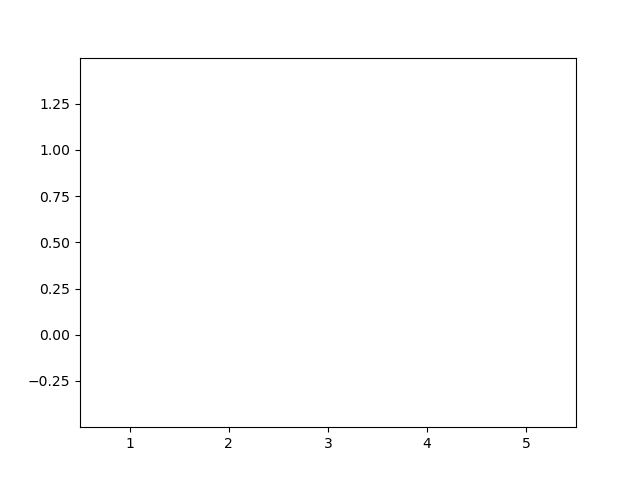

In [66]:
fig1 = plt.figure()
ax1 = plt.axes()
plt.axis([x_min-0.5, x_max+0.5, y_min-0.5, y_max+0.5])
line1, = ax1.plot([], [],'b')
FuncAnimation(fig1, at_frame1, frames=matrix, repeat=False, interval=15)

Для повторного воспроизведения анимации нужно запустить предыдующую ячейку
кода снова.

В результате многочисленных запусков анимации может накопиться много
объектов графических окон. Функция close удалит это объекты

In [50]:
plt.close('all')

## Реализация Задания 3.1b

Создайте аналогичную анимацию построения графика параметрически заданной функции изменяющимся от $x = x(t),y = y(t)$ по значениям $t$, последовательно изменяющимся от $t_{min}$ до $t_{max}$ с шагом $step$. Выполните задание для функции из Задания 1.4 в Лб1, согласно Вашему варианту. Значения и $t_{min}$ и $t_{max}$ выберите самостоятельно с учетом непрерывности параметрической функции на выбранном диапазоне, $step = (tmax −tmin)/100$.

In [68]:
t_array52 = np.logspace(np.log(np.e**(-10)),np.log(np.pi/2 - 0.00001),1000,True,np.e)

In [54]:
x1_array = 1/np.tan(2*t_array52)
y1_array = np.log(np.tan(t_array52))

In [70]:
matrix1 = np.transpose([x1_array, y1_array])

In [72]:
y1_min, y1_max = np.min(y1_array), np.max(y1_array)
x1_min, x1_max = -10, np.max(x1_array)
ax2 = plt.axes()
plt.axis([x1_min-0.5, x1_max+0.5, y1_min-0.5, y1_max+0.5])

(-10.5, 11013.732867136732, -10.499999999312948, 12.012925464924221)

In [76]:
line2, = ax2.plot([],[],'b') 
print(type(line1))
line2.get_xdata(), line2.get_ydata()

<class 'matplotlib.lines.Line2D'>


(array([], dtype=float64), array([], dtype=float64))

In [78]:
def at_frame2(point):

    x1_coord = list(line2.get_xdata())
    y1_coord = list(line2.get_ydata())
    
    x1_coord.append(point[0])
    y1_coord.append(point[1])
    
    line2.set_data(x1_coord, y1_coord) 

In [80]:
print(at_frame1.__doc__)

добавляет к объекту line1 точку с координатами (point[0],point[1])
       Arguments :
       point : массив из двух элементов
       Returns : None
       


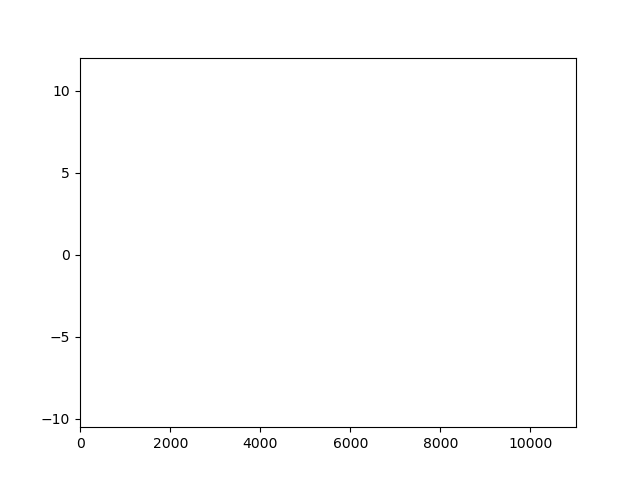

In [82]:
fig2 = plt.figure()
ax2 = plt.axes()
plt.axis([x1_min-0.5, x1_max+0.5, y1_min-0.5, y1_max+0.5])
line2, = ax2.plot([], [],'b')
FuncAnimation(fig2, at_frame2, frames=matrix1, repeat=False, interval=15)

In [84]:
plt.close('all')

## Задание 3.2. Движение точки по линии на плоскости

Создайте анимацию движения точки по графику функции $x = x(t), y = y(t)$ по значениям $t$, последовательно изменяющимся от $t_{min}$ до $t_{max}$ с шагом $step$. Функция $x = x(t),y = y(t)$ и значения переменных $t_{min}$, $t_{max}$, $step$
такими же, как и при выполнении Задания 3.1b.

##  Реализация Задания 3.2 для функции $y(x) = sin(x)^4$

 Последовательно выполним следущие действия с использованием функций из модуля pyplot:
- с помощью функции figure создадим графическое окно, в котором в дальнейшем будет отображаться анимация;
- с помощью функции axes cоздадим графическую область и зададим для нее пределы по осям с помощью функции axis;
- с помощью функции plot создадим в графической области графический объект типа Line2D синего цвета 'b', координаты которого описывают аналитическую функцию;
- с помощью функции plot создадим в графической области графический объект типа Line2D зеленого цвета с маркером в виде кружка 'go' координаты которого пока неизвестны.

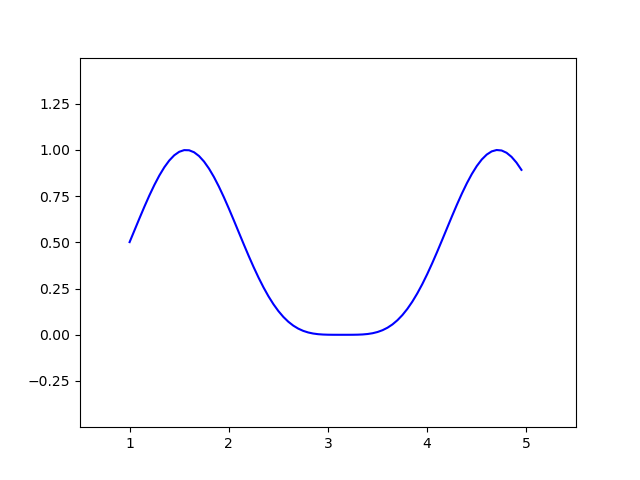

In [31]:
fig3 = plt.figure()

ax3 = plt.axes()
plt.axis([x_min-0.5, x_max+0.5, y_min-0.5, y_max+0.5])

line1, = ax3.plot(x_array, y_array,'b')  # объект для графика функции
line3, = ax3.plot([], [],'go') # объект для точки

Определим пользовательскую функцию одного аргумента at_frame2, которая будет вызываться в каждом кадре анимации.

Единственный аргумент функции at_frame2, является массивом из $x$ и $y$ координат точки графика функции. Функция at_frame2 задает графический объект line2 единственной точкой с 
координатами (x, y)

In [32]:
def at_frame3(point):
    """задает объект line2 точкой с координатами (point[0],point[1])
    Arguments :
    point : массив из двух элементов
    Returns : None
    """
    line3.set_data([point[0]],[point[1]])

Полагаем аргумент init_func функции FunAnimation равным пользовательской init: init_func=init. Функция init будет вызываться перед началом анимации. Назначение функции init: отображение графика функции, создание графика для отображения точки и создание легенды для двух графиков.

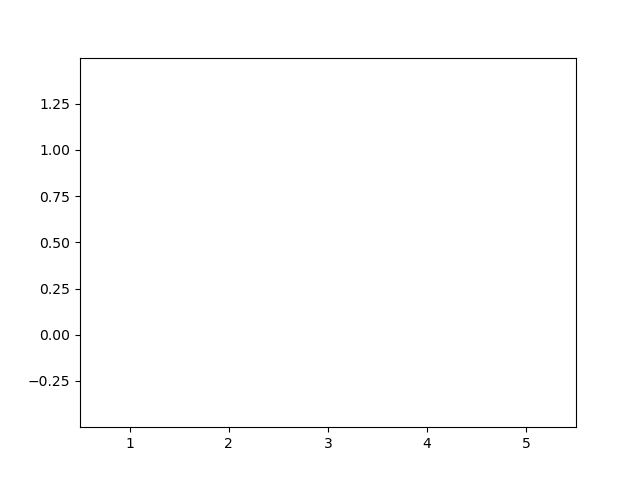

In [33]:
fig3 = plt.figure()
ax3 = plt.axes()
plt.axis([x_min-0.5, x_max+0.5, y_min-0.5, y_max+0.5])

def init():
    """создает начальное состояние графической области"""
    global line3 # переменная сделана глобальной, чтобы она могла изменяться вну
    
    line1, = ax3.plot(x_array, y_array,'b')  
    line3, = ax3.plot([], [],'go') 
    plt.legend([r'$y(x) = \sin(x)^4$','Мovable point'])

FuncAnimation(fig3, at_frame3, frames=matrix, init_func=init, repeat=False, interval=20)

In [34]:
plt.close('all')

Создайте аналогичную анимацию для функции x =x(t),y = y(t) из Задания 3.1b.

##  Реализация Задания 3.2 для функции $x=cot(2e^t), y = ln(tan(e^t))$

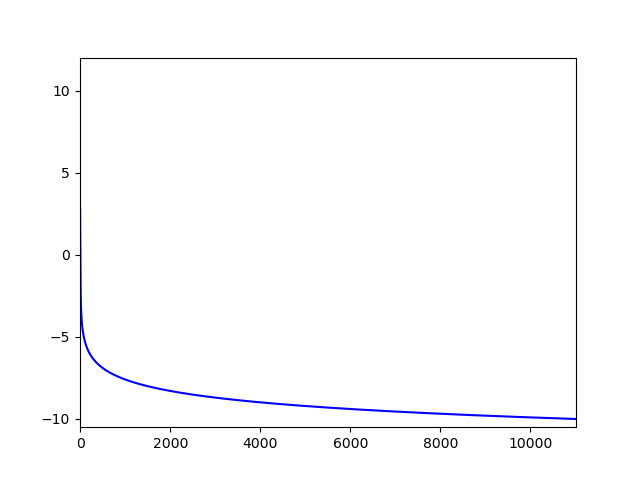

In [35]:
fig4 = plt.figure()

ax4 = plt.axes()
plt.axis([x1_min-0.5, x1_max+0.5, y1_min-0.5, y1_max+0.5])

line2, = ax4.plot(x1_array, y1_array,'b')  # объект для графика функции
line4, = ax4.plot([], [],'go') # объект для точки

In [36]:
def at_frame4(point):
    
    line4.set_data([point[0]],[point[1]])

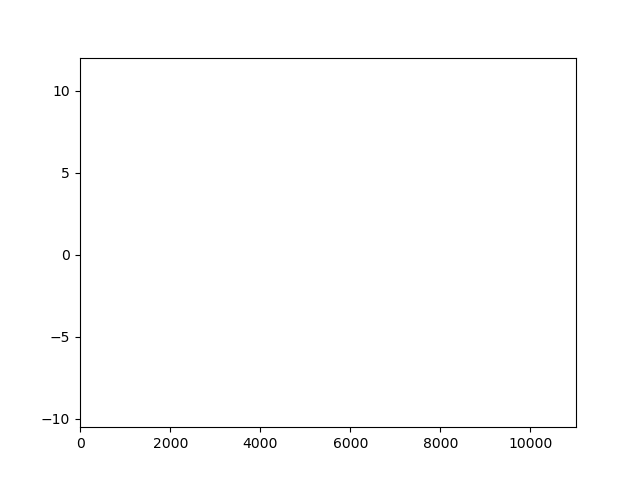

In [37]:
fig4 = plt.figure()
ax4 = plt.axes()
plt.axis([x1_min-0.5, x1_max+0.5, y1_min-0.5, y1_max+0.5])

def init():
    """создает начальное состояние графической области"""
    global line4 # переменная сделана глобальной, чтобы она могла изменяться вну
    
    line2, = ax4.plot(x1_array, y1_array,'b')  
    line4, = ax4.plot([], [],'go') 
    plt.legend([r'$y(x) = \sin(x)^4$','Мovable point'])

FuncAnimation(fig4, at_frame4, frames=matrix1, init_func=init, repeat=False, interval=20)

##  Задание 3.3. Движение секущей прямой к заданной линии на плоскости (версия 1)

Линия на плоскости задана графиком параметрической функции $x = x(t), y = y(t)$ для $t ∈ [t_{min},t_{max}]$ из Задания 3.1b. Начальная точка *$A$* с координатами $(x(t_{min}), y(t_{max}))$ является неподвижной точкой. Точка *$B$* движется последовательно по линии от конечной точки кривой с координатами
$(x(t_{min}), y(t_{max}))$ к неподвижной точке *$A$*.

Создайте анимацию движения секущей прямой, проходящей через точки *$A$* и *$B$*, до момента совпадении координат точек *$A$* и *$B$*, когда секущая прямая становится касательной прямой к заданной линии в начальной точке *$A$*.

##  Реализация Задания 3.3 для функции $y(x) = sin(x)^4$

Перед началом анимации графическая область должна содержать следующие графические объекты:

- график заданной функции, которая определяет траекторию движения подвижной точки *$B$*;
- неподвижную точку *$A$*;
- начальное положение подвижной точки *$B$*;
- cекущую прямую, проходящую через точки *$A$* и *$B$*.

Начальное состояние графической области реализуем с помощью пользовательской функции init.

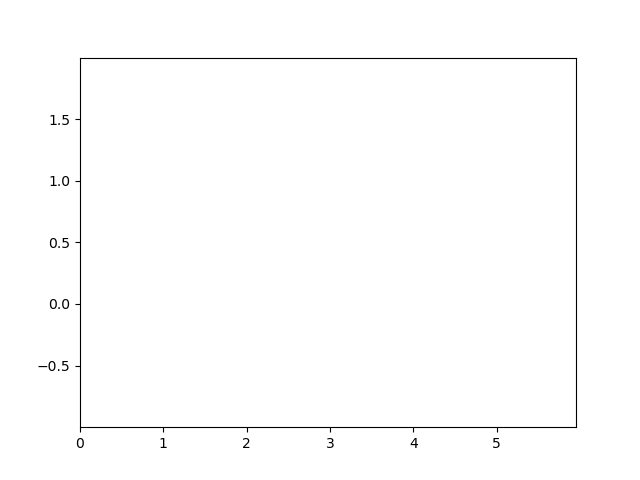

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import sympy as sp

x_min = 1.; x_max = 5.; step = 0.05
x_array = np.arange(x_min, x_max, step)
y_array = np.sin(x_array)**4
y_min, y_max = np.min(y_array), np.max(y_array)
x_min, x_max = np.min(x_array), np.max(x_array)

x_sym = sp.symbols('x')
f_sym = sp.sin(x_sym)**4
f_prime_sym = sp.diff(f_sym, x_sym)

f_prime = sp.lambdify(x_sym, f_prime_sym, 'numpy')

# Создание фигуры и осей
fig3 = plt.figure()
ax3 = plt.axes()
plt.axis([x_min - 1, x_max + 1, y_min - 1, y_max + 1])

def init():
    """Создает начальное состояние графической области перед началом анимации."""
    global point_A, point_B, secant_line, tangent_line  # Глобальные переменные

    curve, = ax3.plot(x_array, y_array, 'b')  # График исходной функции

    A = np.array([x_array[0], y_array[0]])
    point_A, = ax3.plot(A[0], A[1], 'ro')

    B = np.array([x_array[-1], y_array[-1]])
    point_B, = ax3.plot(B[0], B[1], 'go')

    # Секущая линия
    secant_p = [A + (B - A) * t for t in [-2, 2]]
    secant_p = np.array(secant_p)
    secant_line, = ax3.plot(secant_p[:, 0], secant_p[:, 1], 'g')

    tangent_line, = ax3.plot([], [], 'r')

    plt.legend([r'$y(x) = \sin(x)^4$','Unmovable point A','Мovable point B','Seс'])
    return curve, point_A, point_B, secant_line, tangent_line

def at_frame3(point):
    """Обновляет положение точки B и линии (секущей или касательной) на каждом кадре."""
    global secant_line, tangent_line

    # Обновляем точки А и В
    point_B.set_data([point[0]], [point[1]])
    A = np.array([x_array[0], y_array[0]])

    # Если точки совпадают
    if np.allclose(A, point):
        k = f_prime(A[0])
        tangent_p = [A + np.array([1, k]) * t for t in [-100, 100]]  # Две точки касательной
        tangent_p = np.array(tangent_p)

        tangent_line.set_data(tangent_p[:, 0], tangent_p[:, 1])
        secant_line.set_data([], [])
    # Если точки не совпадают
    else:
        secant_p = [A + (point - A) * t for t in [-100, 100]]
        secant_p = np.array(secant_p)
        secant_line.set_data(secant_p[:, 0], secant_p[:, 1])
        tangent_line.set_data([], [])

    plt.legend([r'$y(x) = \sin(x)^4$','Unmovable point A','Мovable point B','Tan'])
    return point_B, secant_line, tangent_line

FuncAnimation(fig3, at_frame3, frames=matrix[::-1], 
              init_func=init, repeat=False, interval=20)

In [88]:
plt.close('all')

Напишите пользовательскую функцию at_frame3(t) , которая будет вызываться в каждом кадре анимации, полагая, что аргумент point является массивом координат подвижной точки *$B$*. Напишите строки документации для пользовательской функции at_frame3 .

Обратите внимание, что при совпадении координат неподвижной точки *$A$* и подвижной точки *$B$* уравнение для задания секущей прямой через две точки возвращает только точку *$A$*. В этом случае векторно-параметрическое уравнение прямой должно быть заменено на уравнение касательной прямой в точке *$A$*. Вычисление производной в точке *$A$*, необходимое для построения касательной прямой, осуществите с помощью возможностей модуля sympy. Касательную прямую изобразите красным цветом.

In [40]:
t_array52 = np.logspace(np.log(np.e**(-10)),np.log(np.pi/2 - 0.00001),1000,True,np.e)

In [41]:
x1_array = 1/np.tan(2*t_array52)
y1_array = np.log(np.tan(t_array52))

In [42]:
matrix1 = np.transpose([x1_array, y1_array])

(-10.5, 11013.732867136732, -10.499999999312948, 12.012925464924221)

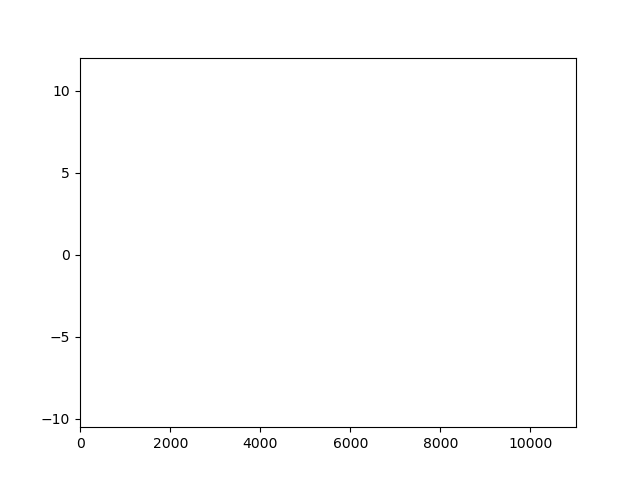

In [43]:
y1_min, y1_max = np.min(y1_array), np.max(y1_array)
x1_min, x1_max = -10, np.max(x1_array)
ax2 = plt.axes()
plt.axis([x1_min-0.5, x1_max+0.5, y1_min-0.5, y1_max+0.5])

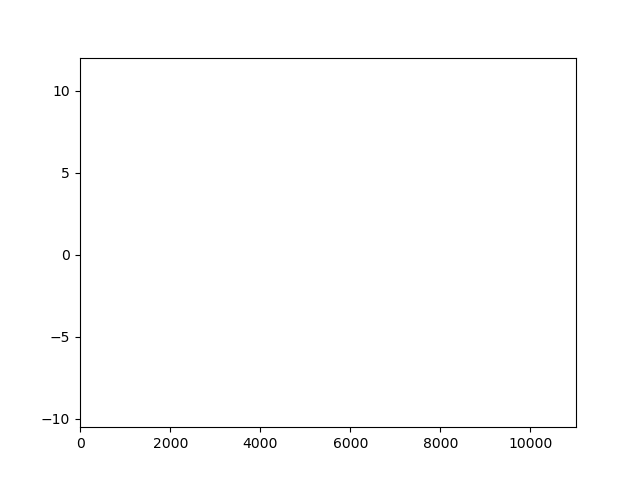

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import sympy as sp

t_array52 = np.logspace(np.log(np.e**(-10)),np.log(np.pi/2 - 0.00001),1000,True,np.e)
x1_array = 1/np.tan(2*t_array52)
y1_array = np.log(np.tan(t_array52))
y1_min, y1_max = np.min(y1_array), np.max(y1_array)
x1_min, x1_max = -10, np.max(x1_array)

t = sp.symbols('t')

x = 1 / sp.tan(2 * t)  # x(t) = ctg(2t)
y = sp.log(sp.tan(t))   # y(t) = ln(tan(t))

dx_dt = sp.diff(x, t)
dy_dt = sp.diff(y, t)

f2_prime_sym = dy_dt / dx_dt

f2_prime = sp.lambdify(t, f2_prime_sym, 'numpy')


# Создание фигуры и осей
fig2 = plt.figure()
ax2 = plt.axes()
plt.axis([x1_min-0.5, x1_max+0.5, y1_min-0.5, y1_max+0.5])

def init():
    """Создает начальное состояние графической области перед началом анимации."""
    global point_A, point_B, secant_line, tangent_line  # Глобальные переменные

    curve, = ax2.plot(x1_array, y1_array, 'b')  # График исходной функции

    A = np.array([x1_array[0], y1_array[0]])
    point_A, = ax2.plot(A[0], A[1], 'ro')

    B = np.array([x1_array[-1], y1_array[-1]])
    point_B, = ax2.plot(B[0], B[1], 'go')

    # Секущая линия
    secant_p = [A + (B - A) * t for t in [-2, 2]]
    secant_p = np.array(secant_p)
    secant_line, = ax2.plot(secant_p[:, 0], secant_p[:, 1], 'g')

    # Касательная линия (пока не отображается)
    tangent_line, = ax2.plot([], [], 'r')

    plt.legend([r'$y(x) = \sin(x)^4$','Unmovable point A','Мovable point B','Seс'])
    return curve, point_A, point_B, secant_line, tangent_line

def at_frame3(point):
    """
    Обновляет положение точки B и линии (секущей или касательной) на каждом кадре анимации.

    Функция вызывается на каждом кадре анимации и выполняет следующие действия:
    1. Обновляет положение точки B на графике.
    2. Проверяет, совпадают ли точки A и B.
       - Если точки совпадают, строится касательная к функции в точке A.
       - Если точки не совпадают, строится секущая линия, проходящая через точки A и B.
    3. Возвращает обновленные графические объекты для отображения на текущем кадре.

    Параметры:
    ----------
    point : numpy.ndarray
        Текущие координаты точки B в виде массива [x, y].

    Возвращает:
    ----------
    tuple
        Кортеж из обновленных графических объектов:
        - point_B: Графический объект точки B.
        - secant_line: Графический объект секущей линии.
        - tangent_line: Графический объект касательной линии.

    Логика работы:
    -------------
    - Если точки A и B совпадают (с учетом погрешности np.allclose), строится касательная
      с использованием производной функции в точке A. Секущая линия скрывается.
    - Если точки A и B не совпадают, строится секущая линия, проходящая через A и B.
      Касательная линия скрывается.
    """
    global secant_line, tangent_line

    # Обновляем точки А и В
    point_B.set_data([point[0]], [point[1]])
    A = np.array([x1_array[0], y1_array[0]])

    # Если точки совпадают
    if np.allclose(A, point):
        k = f2_prime(t_array52[0])
        tangent_p = [A + np.array([1, k]) * t for t in [-20000, 20000]]  # Две точки касательной
        tangent_p = np.array(tangent_p)

        tangent_line.set_data(tangent_p[:, 0], tangent_p[:, 1])
        secant_line.set_data([], [])
    # Если точки не совпадают
    else:
        secant_p = [A + (point - A) * t for t in [-100, 100]]
        secant_p = np.array(secant_p)
        secant_line.set_data(secant_p[:, 0], secant_p[:, 1])
        tangent_line.set_data([], [])

    return point_B, secant_line, tangent_line

FuncAnimation(fig2, at_frame3, frames=matrix1[::-1], 
              init_func=init, repeat=False, interval=20)

In [45]:
plt.close('all')

## Задание 3.4. Движение секущей прямой к заданной линии на плоскости 

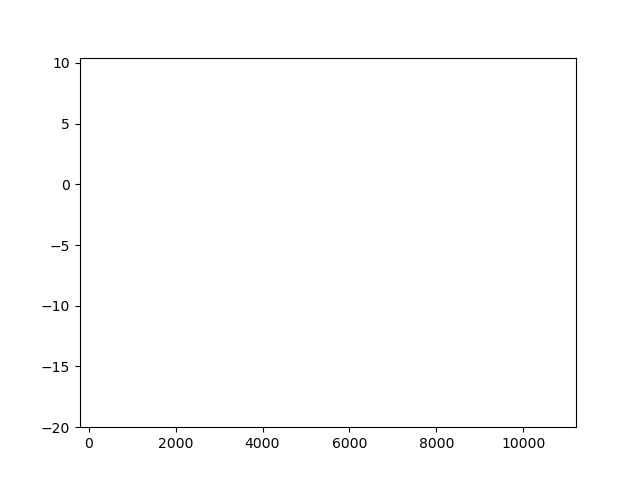

In [92]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import sympy as sp

t_array52 = np.logspace(np.log(np.e**(-10)),0, 100,True,np.e) 
x1_array = 1/np.tan(2*t_array52)
y1_array = np.log(np.tan(t_array52))
y1_min, y1_max = np.min(y1_array), np.max(y1_array)
x1_min, x1_max = np.min(x1_array), np.max(x1_array)

t = sp.symbols('t')

x = 1 / sp.tan(2 * t)  # x(t) = ctg(2t)
y = sp.log(sp.tan(t))   # y(t) = ln(tan(t))

dx_dt = sp.diff(x, t)
dy_dt = sp.diff(y, t)

f2_prime_sym = dy_dt / dx_dt

f2_prime = sp.lambdify(t, f2_prime_sym, 'numpy')


# Создание фигуры и осей
fig2 = plt.figure()
ax2 = plt.axes()
plt.axis([x1_min-200, x1_max+200, y1_min-10, y1_max+10])

def init():
    """Создает начальное состояние графической области перед началом анимации."""
    global point_A, point_B, secant_line, tangent_line  # Глобальные переменные

    curve, = ax2.plot(x1_array, y1_array, 'b')  # График исходной функции

    A = np.array([x1_array[0], y1_array[0]])
    point_A, = ax2.plot(A[0], A[1], 'ro')

    B = np.array([x1_array[-1], y1_array[-1]])
    point_B, = ax2.plot(B[0], B[1], 'go')

    # Секущая линия
    secant_p = [A + (B - A) * t for t in [-2, 2]]
    secant_p = np.array(secant_p)
    secant_line, = ax2.plot(secant_p[:, 0], secant_p[:, 1], 'g')

    # Касательная линия (пока не отображается)
    tangent_line, = ax2.plot([], [], 'r')

    plt.legend([r'$y(x) = \sin(x)^4$','Unmovable point A','Мovable point B','Seс'])
    return curve, point_A, point_B, secant_line, tangent_line

def at_frame3(point):

    global secant_line, tangent_line

    # Обновляем точки А и В
    point_A.set_data([point[0]], [point[1]])
    B = np.array([x1_array[-1], y1_array[-1]])

    # Если точки совпадают
    if np.allclose(A, B):
        k = f2_prime(t_array52[0])
        tangent_p = [A + np.array([1, k]) * t for t in [-20000, 20000]]  # Две точки касательной
        tangent_p = np.array(tangent_p)

        tangent_line.set_data(tangent_p[:, 0], tangent_p[:, 1])
        secant_line.set_data([], [])
    # Если точки не совпадают
    else:
        secant_p = np.array([A + (B - A) * t for t in [-10e10, 10e10]])
        secant_line.set_data(secant_p[:, 0], secant_p[:, 1])
        tangent_line.set_data([], [])
        
    return point_B, secant_line, tangent_line

FuncAnimation(fig2, at_frame3, frames=matrix1, init_func=init, repeat=False, interval=20)

In [94]:
plt.close('all')